# Detect Faces and Blur Faces
## Description
In this file we use a code for detecting faces in images or videos, and then blurring it based on the regions of the face that we detected

# Requirements

In [1]:
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt

# Load Models

In [2]:
# Define the path to the prototxt file using os.path.join for cross-platform compatibility
prototxt_path = os.path.join("models", "deploy.prototxt")

# Define the path to the caffemodel file using os.path.join for cross-platform compatibility
model_path = os.path.join("models", "res10_300x300_ssd_iter_140000_fp16.caffemodel")

# Load the pre-trained Caffe model from the specified files 
# The readNetFromCaffe function loads the network architecture from the prototxt file and the trained weights from the caffemodel file
model = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)


# Face Detection and Blur Function

This function, `face_blur`, takes an input image and applies Gaussian blur specifically to detected face regions to anonymize them. First, it creates a copy of the input to avoid altering the original image. It calculates kernel sizes for the blur based on the image dimensions to ensure the blur is proportional to the face size. Using a pre-loaded neural network model, it performs face detection by preprocessing the image into a blob and running a forward pass through the model to get detections. For each detected face with confidence above 0.4, it extracts the bounding box, isolates the face region, applies Gaussian blur with the calculated kernel, and replaces the original face with the blurred version. The function finally returns the modified image with all detected faces blurred, preserving privacy while maintaining the rest of the image intact.

In [3]:
def face_blur(image: np.ndarray):
    # Create a copy of the input image to avoid modifying the original image (critical)
    image = image.copy()
    # Get the height and width of the image
    h, w = image.shape[:2]

    # Define the kernel width and height for Gaussian blurring
    # Ensure they are odd numbers by performing a bitwise OR with 1
    kernel_width = (w // 7) | 1
    kernel_height = (h // 7) | 1

    # Create a blob from the image for input to the neural network
    blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300), (104.0, 177.0, 123.0))

    # Set the input for the network
    model.setInput(blob)

    # Perform forward pass to get the output detections
    output = np.squeeze(model.forward())

    # Loop over all detections
    for i in range(0, output.shape[0]):
        # Get the confidence of the detection
        confidence = output[i, 2]

        # Proceed only if the confidence is above the threshold (0.4)
        if confidence > 0.4:
            # Get the bounding box coordinates and scale them to the original image size
            box = output[i, 3:7] * np.array([w, h, w, h])
            start_x, start_y, end_x, end_y = box.astype(int)

            # Extract the face region from the image
            face = image[start_y:end_y, start_x:end_x]

            # Apply Gaussian blur to the face region
            face = cv2.GaussianBlur(face, (kernel_width, kernel_height), 0)

            # Replace the original face region with the blurred face
            image[start_y:end_y, start_x:end_x] = face

    # Return the modified image with blurred faces
    return image


# Result on Image

In [4]:
# Define the path to the image file using os.path.join for cross-platform compatibility
image_path = os.path.join("images", "musk.jpg")

# Read the input image from the specified path
image = cv2.imread(image_path)

# Convert the image from RGB to BGR format (as OpenCV uses BGR by default)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply the face_blur function to the image to blur detected faces
image_face_blur = face_blur(image)


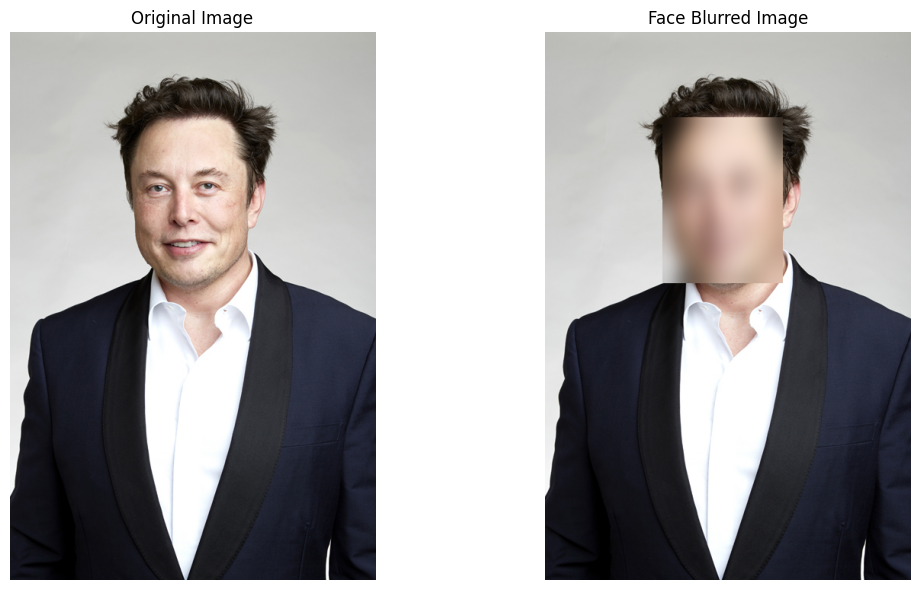

In [5]:
import matplotlib.pyplot as plt

# Create a figure with specified size
plt.figure(figsize=(12, 6))

# Display the original image in the first subplot
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Display the blurred image in the second subplot
plt.subplot(1, 2, 2)
plt.imshow(image_face_blur)
plt.title("Face Blurred Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Result on WebCam Video Stream

The `visualize_fps` function overlays the current frames-per-second (FPS) value onto an input image for display purposes. It first checks whether the image is grayscale or colored to decide the text color (white for grayscale, green for colored). The function then defines parameters such as font size, thickness, and text positioning. It formats the FPS value to one decimal place and uses OpenCV’s `putText` method to draw the FPS text in the top-left corner of the image. This visual indicator helps monitor the real-time processing speed during video or image stream processing. The function returns the image with the FPS text drawn on it.

In [6]:
def visualize_fps(image, fps: int):
    # Check if the image is grayscale or colored.
    # If it's grayscale, set the text color to white; if colored, set the text color to green.
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  # White color for grayscale images.
    else:
        text_color = (0, 255, 0)  # Green color for colored images.

    # Define the row size for the text placement.
    row_size = 20 
    # Define the left margin for the text placement.
    left_margin = 24 

    # Set the font size and thickness for the text.
    font_size = 1
    font_thickness = 2

    # Format the FPS value into a string for displaying.
    fps_text = "FPS = {:.1f}".format(fps)
    # Set the text location on the image.
    text_location = (left_margin, row_size)
    
    # Place the FPS text on the image.
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    # Return the modified image with the FPS text.
    return image


Below are the two cells that use the function we have written to capture and blur faces in a video, or the facecam. the first cell is for the facecam detection and blurring and the second cell is for the video detection and blurring.

In [7]:
# Constants for camera settings
CAMERA_DEVICE_ID = 0  # ID for the camera device
IMAGE_WIDTH = 800  # Width of the captured image
IMAGE_HEIGHT = 600  # Height of the captured image
fps = 0  # Initial Frames Per Second (FPS) value

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  # Initialize video capture with the specified camera device ID

        while True:  # Infinite loop to continuously capture frames
            start_time = time.time()  # Record the start time to calculate FPS

            ret, frame = cap.read()  # Capture a single frame from the camera
            if not ret:
                break


            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT)) # TODO  # Resize the frame to the specified dimensions
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = face_blur(frame)  # Apply the face_blur function to the frame
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR) 

            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps)) 

            end_time = time.time() # TDOD  # Record the end time to calculate FPS

            # Calculate the time taken to process the frame
            seconds = end_time - start_time
            # Calculate FPS based on the time taken to process the frame
            fps = 1.0 / seconds if seconds > 0 else 0

            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(1) == 27:  
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the camera resource


In [11]:
# Define the path to the video file using os.path.join for cross-platform compatibility
CAMERA_DEVICE_ID = os.path.join("videos", "Jobs_2.mp4")
# Constants for video settings
IMAGE_WIDTH = 1000  # Width of the displayed image
IMAGE_HEIGHT = 600  # Height of the displayed image
fps = 0  # Initial Frames Per Second (FPS) value
FRAME_RATE = 30  # Desired frame rate
DURATION = 1 / FRAME_RATE  # Duration of each frame

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID) # Initialize video capture with the specified video file path

        while True:  # Infinite loop to continuously capture frames
            start_time = time.time() # Record the start time to calculate FPS

            ret, frame = cap.read()  # Capture a single frame from the video
            if not ret:
                break
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = face_blur(frame)  # Apply the face_blur function
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            

            end_time = time.time() # Record the end time to calculate FPS
            seconds = end_time - start_time # Calculate the time taken to process the frame

            if seconds < DURATION:  # If the processing time is less than the desired frame duration, wait for the remaining time
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time # Recalculate the time taken to process the frame including sleep time
            fps = 1.0 / seconds if seconds > 0 else 0  # Calculate FPS based on the time taken to process the frame

            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps))

            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(1) == 27:
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the video capture resource
